### Human gastruloid plots

In [1]:
import pandas as pd
import os
import json
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt
import pydeseq2 as deseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.preprocessing import deseq2_norm

from custom_functions import *

save_format = "svg"

In [2]:
human_file = "../data/wnt_nodal_rnaseq/Human_gastruloids_bulk-Raw_counts.xlsx"  # replace with path

counts = pd.read_excel(human_file, index_col=1)
counts.drop(columns='gene_ID', inplace=True)
counts = counts.T

# kepp hESC, 0h and 24h
counts = counts[counts.index.str.contains(r'hESC|0h|24h|48h')]

# Ensure counts are integers
counts = counts.fillna(0)  # Replace NaNs with 0
counts = counts.astype(int)

counts

gene_symbol,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC136297.1,BX248415.1,AL157886.1,AL392086.3,AL357123.1,AL589743.7,AL355312.5,AC120036.5,AC018931.1,AL731559.1
hESCs_r1,2715,74,1485,249,1114,6,1,1510,1618,1476,...,0,0,0,7,0,0,4,0,0,0
hESCs_r2,2076,48,1047,212,911,6,2,1153,1291,1226,...,0,0,0,8,0,0,6,0,0,0
hESCs_r3,2674,50,1201,242,978,3,0,1358,1660,1517,...,0,0,0,8,0,0,0,0,0,0
0h_r1,2080,62,1383,227,715,7,0,1383,989,1591,...,0,0,0,6,0,0,0,0,2,1
0h_r2,1955,81,1662,233,636,3,0,1544,1117,1579,...,0,0,0,16,0,0,0,0,0,0
0h_r3,2425,71,1749,294,882,4,0,1662,1251,1714,...,0,0,0,0,0,0,0,0,0,0
24h_r1,3623,38,2142,462,1416,7,0,1762,1404,2569,...,0,0,0,0,0,0,0,0,0,0
24h_r2,3513,53,2455,306,1049,0,0,1319,1371,1476,...,0,0,0,0,0,0,0,0,0,1
24h_r3,3312,34,2002,362,1297,0,1,1421,1299,1851,...,0,0,0,0,0,0,4,0,0,0
48h_r1,6352,42,2267,734,1383,2,0,1425,1022,2534,...,0,0,0,1,0,0,8,0,0,0


In [3]:
# metadata
# Correct metadata creation
metadata = pd.DataFrame({
    'condition': counts.index.to_series().apply(lambda x: x[:-3])
}, index=counts.index)

metadata.head()


,condition
hESCs_r1,hESCs
hESCs_r2,hESCs
hESCs_r3,hESCs
0h_r1,0h
0h_r2,0h


In [4]:
dds = DeseqDataSet(
    counts=counts.values,
    metadata=metadata,
    design_factors="condition",
    refit_cooks=False
)



In [5]:
## Variance Stabilizing Transformation (VST)
#We scale the data normalizing the sum of total counts and producing and scaling to log1p.
# run vst algorithm
# transformed counts are stored in .layers
dds.vst(use_design=True)
# create df with transformed counts
df1= pd.DataFrame(data=dds.layers['vst_counts'],    
             index=dds.obs.index,    
            columns=counts.columns.values)

Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 4.11 seconds.

Fitting dispersion trend curve...
... done in 0.43 seconds.



Genes retained: 1355


<Axes: >

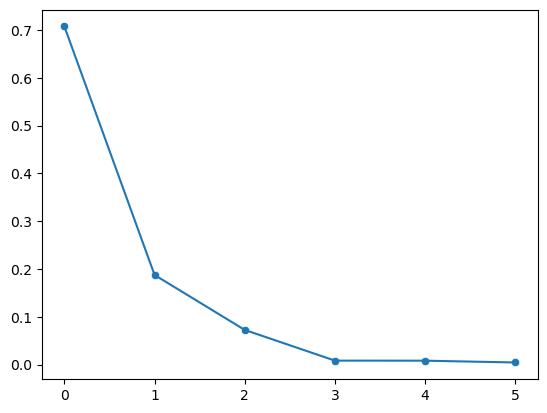

In [6]:
# Free parameters: **threshold**
fs = VarianceThreshold(threshold=0.5)
fs.fit(df1.values)
l1 = fs.get_feature_names_out()
l = [int(i[1:]) for i in l1]

print(f"Genes retained: {len(l)}")
## PCA
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=df1.columns.values[l])
pca = PCA(n_components=6)
pca.fit(df1_fs.values)

sns.lineplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)
sns.scatterplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)

In [7]:

names = df1.columns.values[[int(i[1:]) for i in fs.get_feature_names_out()]]
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=names)

In [8]:
pca = PCA(n_components=min(4,df1.shape[0]-1))
pca.fit(fs.transform(df1.values));
x = pca.transform(fs.transform(df1.values))

dds.obs['PC1']=x[:,0]
dds.obs['PC2']=x[:,1]

In [9]:
dds.obs

,condition,PC1,PC2
hESCs_r1,hESCs,-41.275731,-22.536062
hESCs_r2,hESCs,-41.651245,-22.948471
hESCs_r3,hESCs,-41.284385,-22.626002
0h_r1,0h,-28.029825,26.693681
0h_r2,0h,-27.193393,21.273603
0h_r3,0h,-24.388903,27.566940
24h_r1,24h,25.913033,6.858520
24h_r2,24h,18.374114,9.715527
24h_r3,24h,26.105519,5.452135
48h_r1,48h,45.713780,-11.199379


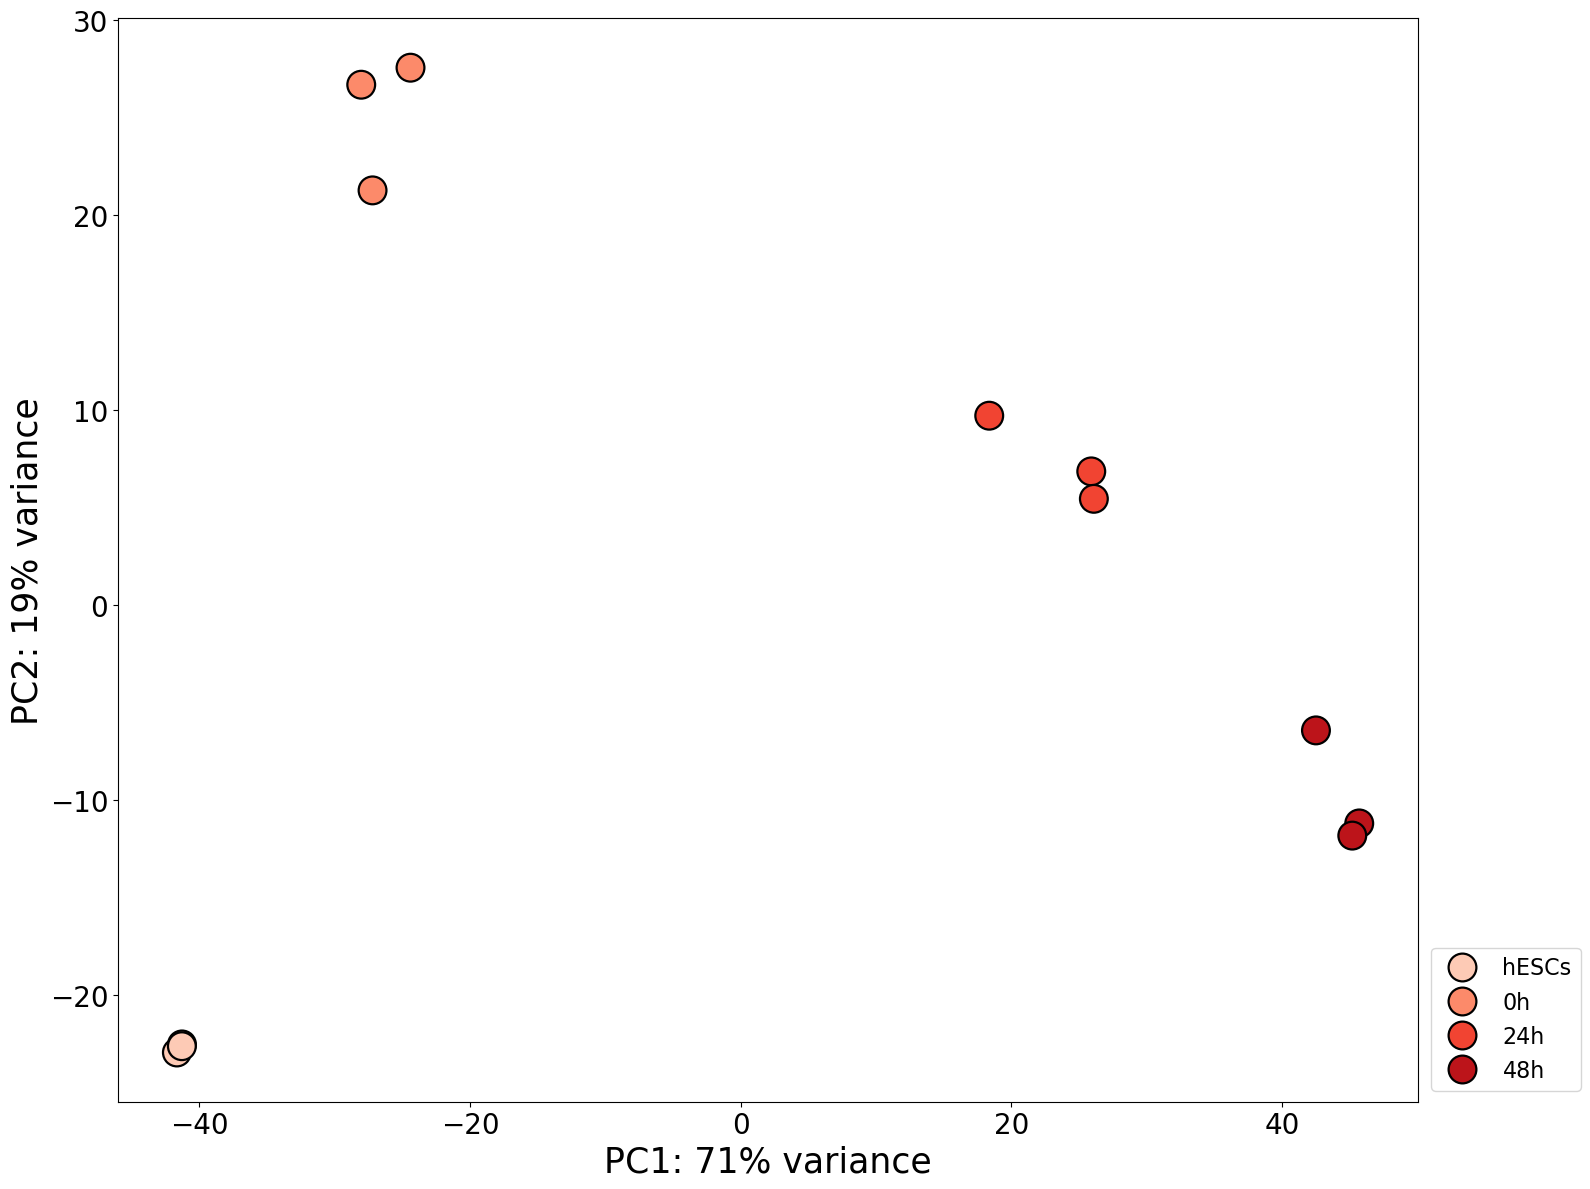

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(16,12))

palette_dict = {
    'hESCs': '#FDBE85',  # light orange
    '0h': "#E2B740",     # light red
    '24h': "#E66814", 
    '48h': "#B95050"   # light purple
}


sns.scatterplot(
    data=dds.obs,
    x='PC1',
    y='PC2',
    hue=dds.obs.condition,
    palette='Reds',
    s=400,
    edgecolor='black',
    ax=ax
)

# Axes labels
ax.set_xlabel(f'PC1: {int(round(pca.explained_variance_ratio_[0]*100))}% variance', fontsize=25)
ax.set_ylabel(f'PC2: {int(round(pca.explained_variance_ratio_[1]*100))}% variance', fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#ax.invert_xaxis()
#ax.invert_yaxis()

# Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, prop={'size':16}, loc=(1.01,0.01))

plt.tight_layout()
plt.savefig(f"../results/human_gastruloids_pca_scatterplot.{save_format}", bbox_inches="tight", transparent=True)
plt.show()

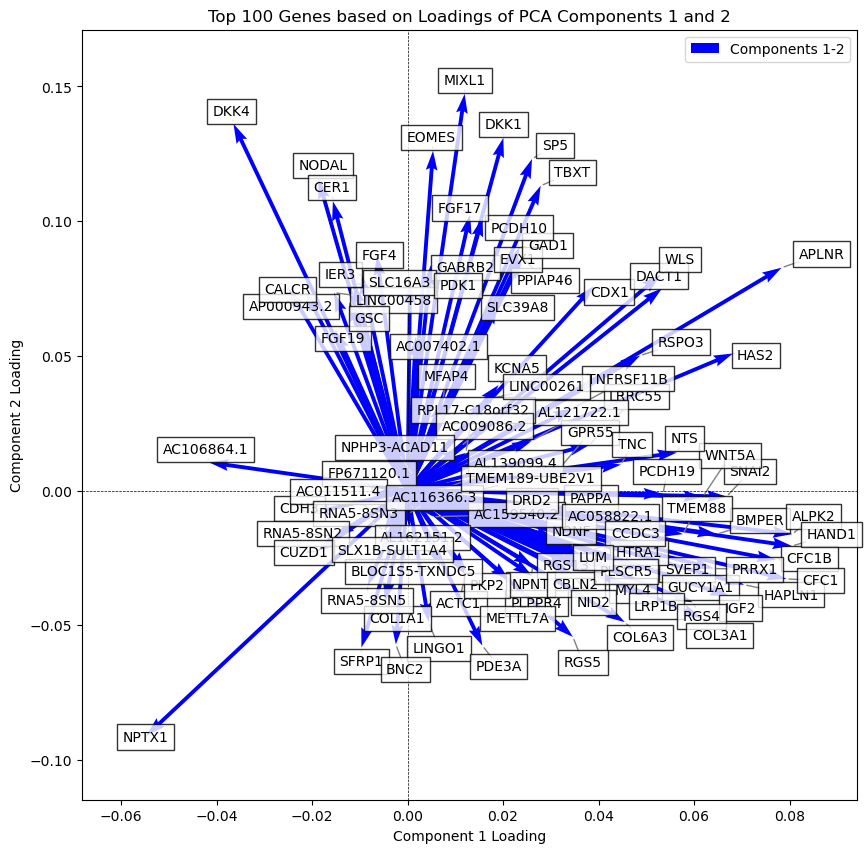

In [11]:
fig,ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,100,ax)

plt.savefig(f"../results/human_gastruloids_analysis_heatmap_100loadings.{save_format}",bbox_inches="tight",transparent=True)

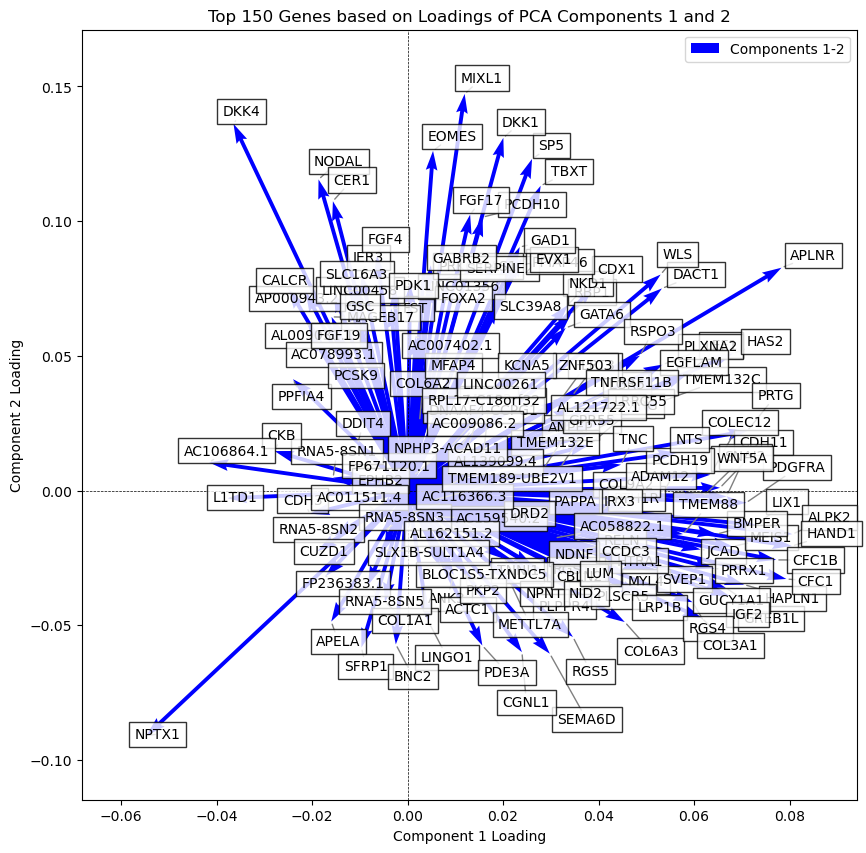

In [12]:
fig,ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,150,ax)

plt.savefig(f"../results/human_gastruloids_analysis_heatmap_150loadings.{save_format}",bbox_inches="tight",transparent=True)

### Lineplots & Heatmaps

In [13]:
genes = ['SOX2','NANOG','EOMES','NODAL','WNT3','TBXT','WNT3A','CDX2','HOXA1','HOXB1']

In [14]:
# normalize and logtransform
df1 = deseq2_norm(counts)[0]
logdf = np.log1p(df1)

logdf_ = logdf.loc[:,genes]

In [15]:
cond_names = [c.rsplit('_', 1)[0] for c in logdf_.columns]

col_map = dict(zip(logdf_.columns, cond_names))
# Rename columns temporarily
logdf_ = logdf_.rename(columns=col_map)

# mean replicates
mean_df = logdf_.groupby(metadata['condition']).mean().T
std_df  = logdf_.groupby(metadata['condition']).std().T


#### Lineplot #1

In [20]:
genes = ['SOX2','NANOG','EOMES','NODAL','WNT3','TBXT','CDX2','HOXA1','HOXB1','WNT3A']


In [30]:
palette = {
    # New purples for pluripotency genes (top of legend)
    "SOX2": "#7E57C2",    # medium purple, CB-friendly
    "NANOG": "#B39DDB",   # lighter purple, CB-friendly

    # Greens (CB-friendly, same as before)
    "EOMES": "#009E73",    # dark green
    "NODAL": "#33B890",    # medium green
    "WNT3":  "#66CCA9",    # light green

    # Reds/Oranges (CB-friendly, same as before)
    "TBXT":  "#D55E00",    # strong red-orange
    "CDX2":  "#E78633",    # softer orange-red
    "HOXA1": "#E69F00",    # golden orange
    "HOXB1": "#F2B670",    # light warm red/orange
    "WNT3A": "#F6D5B8"     # pale peach
}


In [31]:
# Subset and orient (genes as rows, timepoints as columns)
lp1_df = mean_df[["hESCs", "0h", "24h", "48h"]]
lp1_sd = std_df[["hESCs", "0h", "24h", "48h"]]


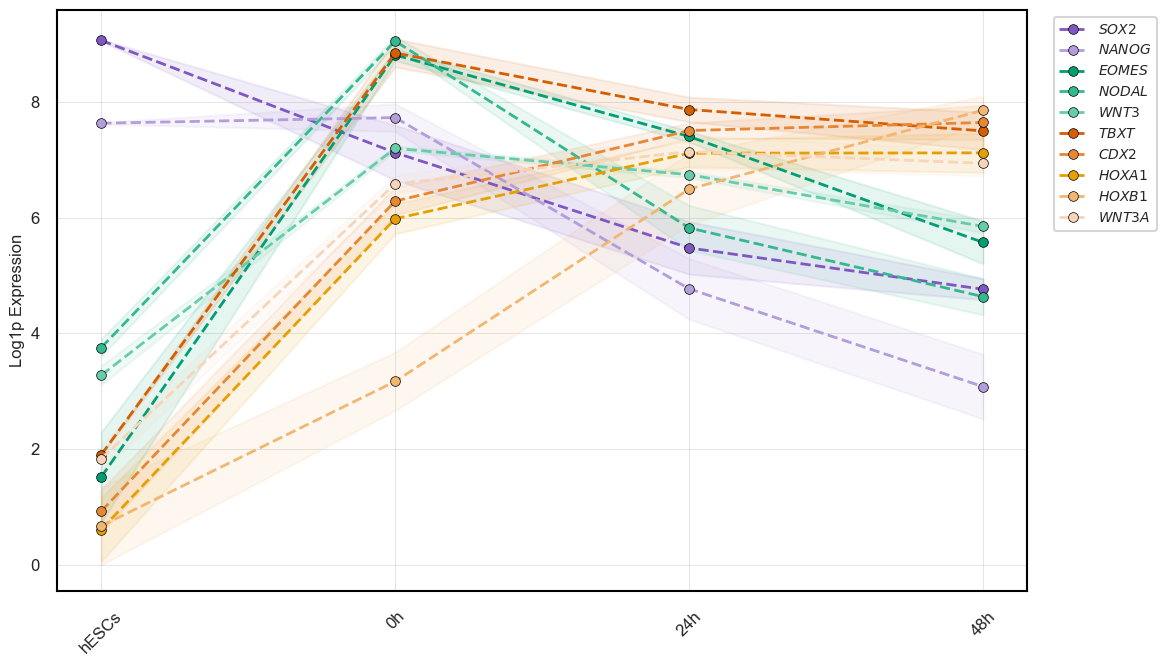

In [32]:
# --- Generate plots ---
save_dir = '../results/'
os.makedirs(save_dir, exist_ok=True)

# construct lineplot v2
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))
ax = plt.gca()
for i, gene in enumerate(genes):
    plt.plot(
        lp1_df.columns,
        lp1_df.loc[gene],
        marker='o',
        markersize=7,
        markeredgecolor='black',
        markeredgewidth=0.5,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )
    plt.fill_between(
        lp1_df.columns,
        lp1_df.loc[gene] - lp1_sd.loc[gene],
        lp1_df.loc[gene] + lp1_sd.loc[gene],
        color=palette[gene],
        alpha=0.1
    )

plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.ylabel('Log1p Expression', fontsize=12)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
plt.tight_layout()
plt.savefig('../results/human_lineplot_1.svg', format='svg')
plt.show()


### Heatmap

In [ ]:
genes = ["POU5F1","ZFP42","NANOG","ESRRB","TFAP2C","PECAM1","KLF5","NR0B1","SOX2","OTX2","HESX1","SOX1","NODAL","WNT3"]


In [ ]:
logdf_ = logdf.loc[:,genes]
logdf_.head()

gene_symbol,POU5F1,ZFP42,NANOG,ESRRB,TFAP2C,PECAM1,KLF5,NR0B1,SOX2,OTX2,HESX1,SOX1,NODAL,WNT3
hESCs_r1,10.264767,8.521579,7.595217,2.627662,5.892729,1.041859,3.744216,1.872332,9.008667,8.039568,5.986867,2.120815,3.866592,3.317815
hESCs_r2,10.322181,8.477532,7.591141,2.273752,6.017721,0.736912,3.868015,1.863671,9.030234,8.095694,5.795849,2.273752,3.694390,3.340627
hESCs_r3,10.237717,8.471931,7.567570,2.952973,5.764720,0.646130,3.569797,2.112046,9.007858,8.069890,5.929756,2.549902,3.569797,3.043528
0h_r1,10.283302,7.960874,7.947255,2.252513,5.761489,1.061765,5.755520,5.154006,7.012428,6.812241,3.037854,0.000000,8.961940,7.163891
0h_r2,10.282642,8.355542,7.480309,2.774065,6.000507,1.099662,5.596280,4.655520,7.589391,6.624309,2.891859,1.387476,9.102881,7.198260
0h_r3,10.038538,8.055612,7.632563,2.167256,5.740534,0.620235,5.914926,4.532084,6.640966,6.923540,3.349893,0.000000,8.960632,7.105556
24h_r1,9.106483,8.089560,4.514269,1.615764,4.855172,0.000000,3.866358,1.229360,5.113800,6.025502,2.508692,0.591306,5.640518,6.751952
24h_r2,9.398246,8.321984,5.321371,2.118335,4.729141,1.235208,4.106895,0.797303,5.950480,6.084083,2.959753,0.797303,6.214197,6.684366
24h_r3,9.158041,8.195677,4.333800,0.000000,4.739279,0.000000,4.237169,1.794350,5.223447,6.123398,2.641943,0.694702,5.471155,6.646893
72h_r1,6.162509,7.285406,1.243220,2.265262,4.249483,1.969472,3.498561,2.493239,4.987290,5.044536,2.970449,1.547591,3.918704,5.412724


In [ ]:
# convert to int 
df1 = df1.astype(int)
df1_meta = pd.DataFrame({
    "Condition": df1.index.map(lambda x: x[:-3])
}, index=df1.index)

df1_meta


,Condition
hESCs_r1,hESCs
hESCs_r2,hESCs
hESCs_r3,hESCs
0h_r1,0h
0h_r2,0h
0h_r3,0h
24h_r1,24h
24h_r2,24h
24h_r3,24h
72h_r1,72h


In [ ]:
dds = DeseqDataSet(
    counts=df1.values,
    metadata=df1_meta,
    design_factors="Condition",
    refit_cooks=True
)

In [ ]:
# vst
dds.vst(use_design=True)
vst_df = pd.DataFrame(dds.layers['vst_counts'], index=dds.obs.index, columns=df1.columns)


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 9.29 seconds.

Fitting dispersion trend curve...
... done in 1.07 seconds.



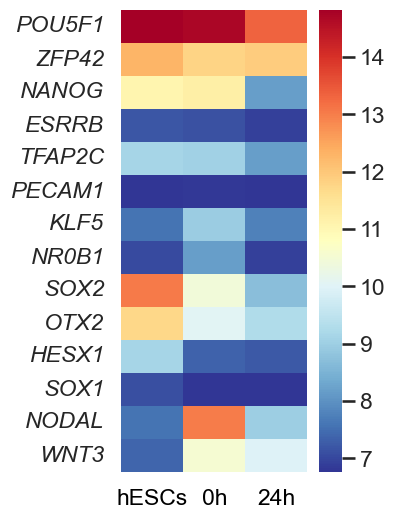

In [ ]:
# retain samples of interest
d_s = vst_df.loc[[c for c in vst_df.index if '72h' not in c],genes]
d_s_mean = d_s.groupby([i[:-3] for i in d_s.index]).mean()
d_s_mean = d_s_mean.loc[["hESCs", "0h", "24h"]]


fig,ax=plt.subplots(1,1, figsize=(3,6))

sns.heatmap(
    d_s_mean.loc[["hESCs", "0h", "24h"]].transpose(),
    cmap="RdYlBu_r",
    ax=ax
)
ax.set_ylabel('')
ax.set_xticklabels(["hESCs", "0h", "24h"],color='black')
ax.tick_params('y', labelrotation=0, color='black')
ax.set_yticklabels(ax.get_yticklabels(), style='italic')

plt.savefig(f"../results/human_gastruloid_heatmap_1.{save_format}",bbox_inches="tight",transparent=True)